In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
from config import config
from utils.audio_data import extract_mel_spectrogram

In [12]:
import librosa, matplotlib.pyplot as plt
from pathlib import Path

In [7]:
root = Path("../..")

In [8]:
RAW_AUDIO_DIR_EN = root / config.RAW_AUDIO_DIR_BN
RAW_AUDIO_DIR_BN = root / config.RAW_AUDIO_DIR_BN

In [9]:
RAW_AUDIO_DIR_EN.exists(), RAW_AUDIO_DIR_BN.exists() # have to be True

(True, True)

In [10]:
en_audio_path = [p for p in RAW_AUDIO_DIR_EN.iterdir() if p.is_file() and p.suffix.lower() == ".wav"][0]
bn_audio_path = [p for p in RAW_AUDIO_DIR_BN.iterdir() if p.is_file() and p.suffix.lower() == ".wav"][0]

In [11]:
y_en, sr = librosa.load(en_audio_path, sr=config.SAMPLE_RATE)
y_bn, sr = librosa.load(bn_audio_path, sr=config.SAMPLE_RATE)

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
en_y_spec = extract_mel_spectrogram(audio_path=en_audio_path)
bn_y_spec = extract_mel_spectrogram(audio_path=bn_audio_path)

In [16]:
en_y_spec

array([[-33.71991 , -29.170835, -37.190857, ..., -37.702255, -39.37924 ,
        -34.03234 ],
       [-25.484375, -20.12613 , -27.283718, ..., -31.141163, -30.48033 ,
        -30.61867 ],
       [-20.14353 , -17.743116, -23.458813, ..., -20.691597, -21.500149,
        -24.401028],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -79.90936 ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(64, 91), dtype=float32)

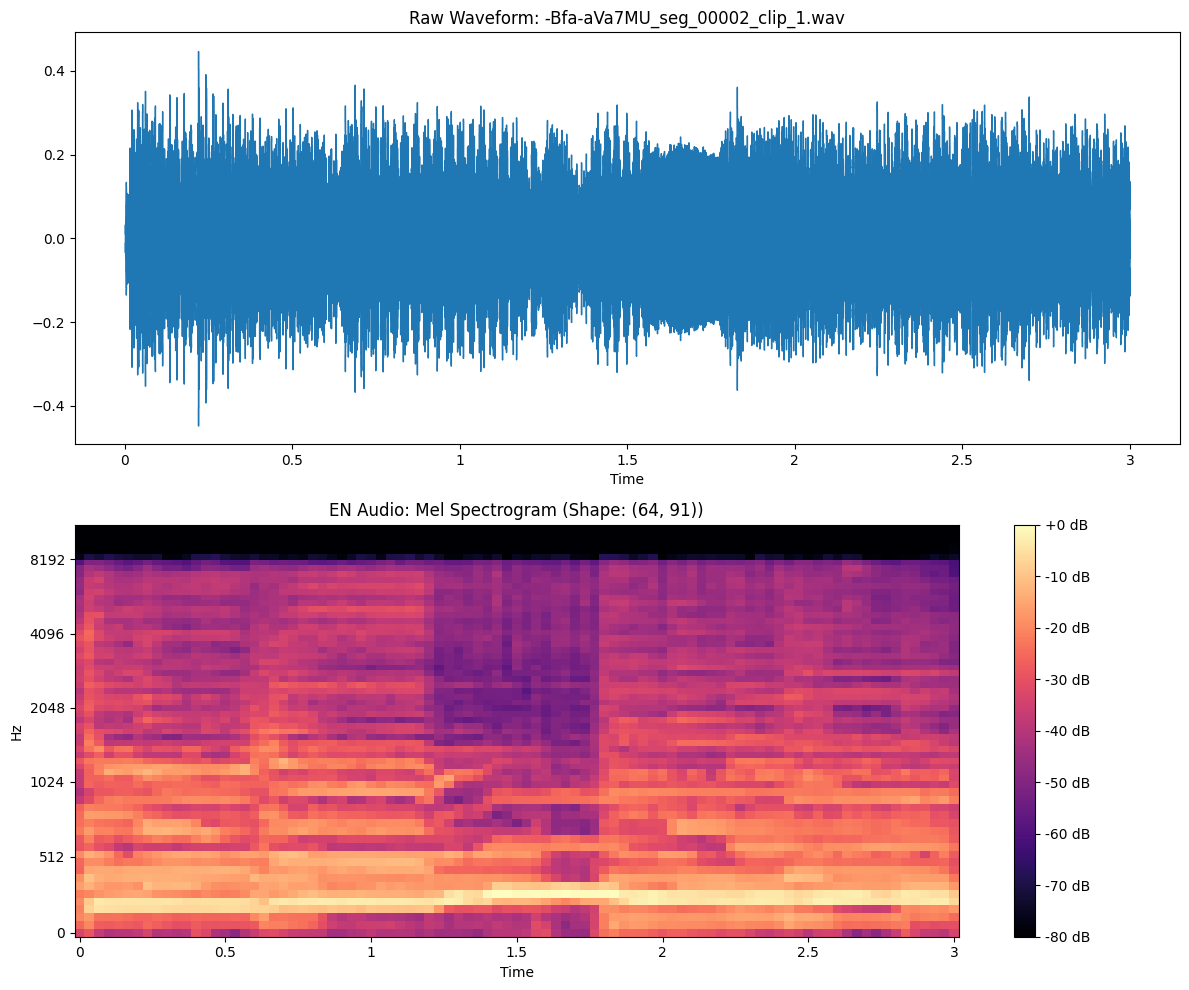

In [21]:
# EN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {en_audio_path.name}")

img = librosa.display.specshow(
    en_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"EN Audio: Mel Spectrogram (Shape: {en_y_spec.shape})")

plt.tight_layout()
plt.show()

In [18]:
bn_y_spec

array([[-33.71991 , -29.170835, -37.190857, ..., -37.702255, -39.37924 ,
        -34.03234 ],
       [-25.484375, -20.12613 , -27.283718, ..., -31.141163, -30.48033 ,
        -30.61867 ],
       [-20.14353 , -17.743116, -23.458813, ..., -20.691597, -21.500149,
        -24.401028],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -79.90936 ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], shape=(64, 91), dtype=float32)

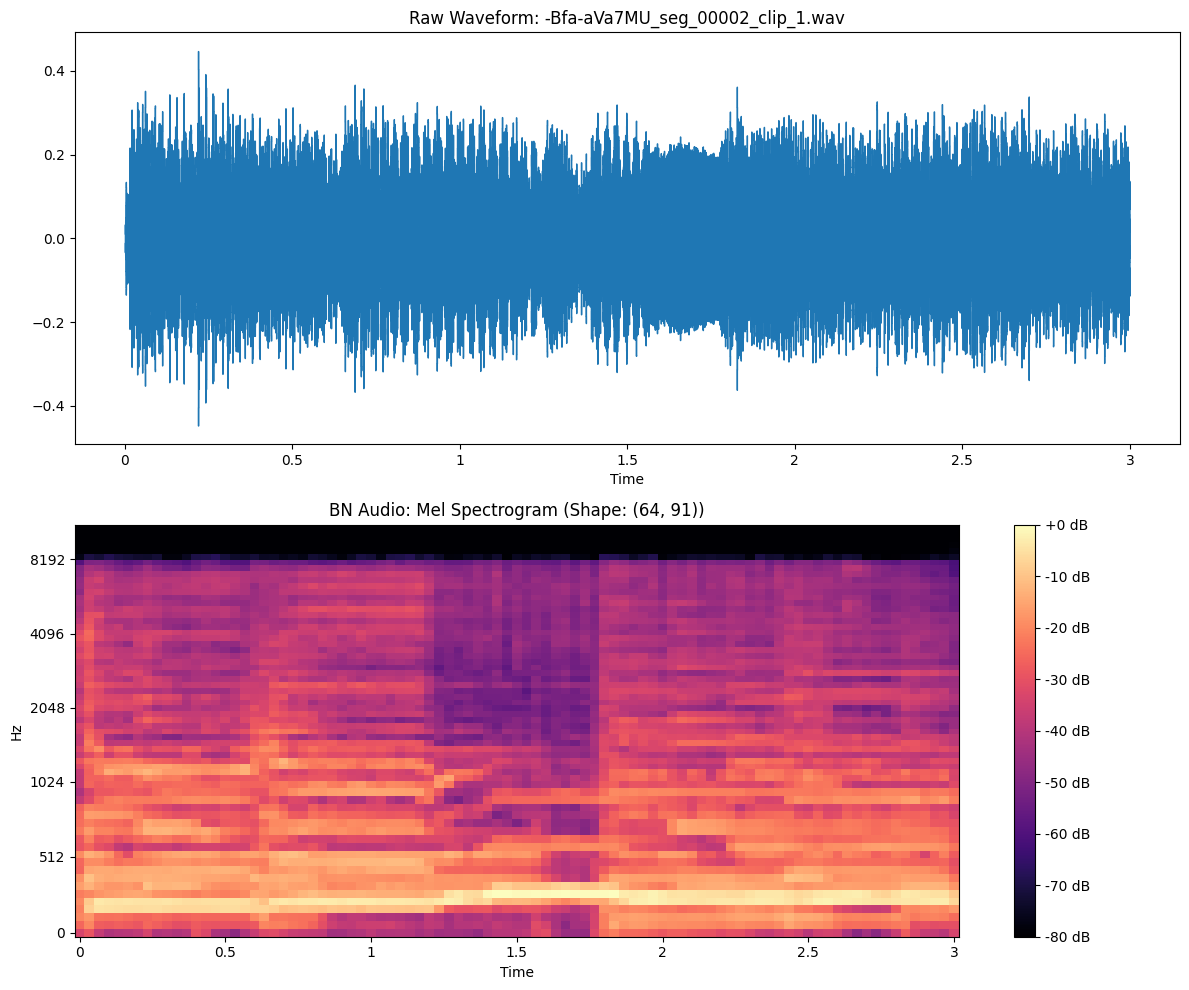

In [20]:
# BN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {bn_audio_path.name}")

img = librosa.display.specshow(
    bn_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"BN Audio: Mel Spectrogram (Shape: {bn_y_spec.shape})")

plt.tight_layout()
plt.show()